ETAPE 1

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

touchpoints = pd.read_csv("Lumina Co CRM/touchpoints.csv")
campaigns = pd.read_csv("Lumina Co CRM/campaigns.csv")
transactions = pd.read_csv("Lumina Co CRM/transactions.csv")
customers = pd.read_csv("Lumina Co CRM/customers.csv")


transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]

In [2]:
transactions_clean = transactions.dropna(subset=["customer_id"])
print(f"{len(transactions) - len(transactions_clean)} lignes exclues ({(1 - len(transactions_clean)/len(transactions))*100:.1f}%)")

367328 lignes exclues (22.8%)


Rappel Jour 1 : 22,8% des transactions n'ont pas de customer_id (achats invités/caisse). Le RFM se calcule par client, donc ces lignes sont mathématiquement impossibles à rattacher à un profil — on les exclut ici, spécifiquement pour ce calcul (elles restent valables pour un CA global si besoin ailleurs).

In [3]:
snapshot_date = transactions_clean["invoice_date"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2026-07-01 00:00:00


Pourquoi pas la date du jour : les données s'arrêtent au 30/06/2026 (vu au Jour 1) — utiliser aujourd'hui gonflerait artificiellement la récence de tous les clients. On prend donc le lendemain du dernier événement du dataset comme point de référence fixe : ça donne une récence de 1 jour minimum (jamais 0), ce qui évite un cas particulier dans les calculs de score plus tard.

In [4]:
rfm = transactions_clean.groupby("customer_id").agg(
    recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum")
).reset_index()

rfm.head()

,customer_id,recency,frequency,monetary
0,12346.0,326,17,701.46
1,12347.0,2,8,7740.74
2,12348.0,75,5,1561.92
3,12349.0,19,5,5342.41
4,12350.0,310,1,554.75


 Récence : jours depuis le dernier achat (date de référence - dernière date d'achat).
 Fréquence : nunique() sur invoice_id, pas count() sur les lignes — une facture avec 5 produits doit compter comme 1 achat, pas 5. Sinon tu confonds fréquence d'achat et nombre d'articles achetés.
 Montant : somme de line_total sur toute la période — inclut les valeurs négatives des retours (vu au Jour 1), ce qui donne un montant net réaliste plutôt que gonflé

In [5]:
rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]

first_purchase = transactions_clean.groupby("customer_id")["invoice_date"].min()
rfm["tenure_days"] = rfm["customer_id"].map(lambda cid: (snapshot_date - first_purchase[cid]).days)

rfm.describe()

,customer_id,recency,frequency,monetary,avg_basket,tenure_days
count,49402.000000,49402.000000,49402.000000,49402.000000,49402.000000,49402.000000
mean,37546.661876,313.241630,4.557326,791.887730,140.209791,541.105097
std,14581.155150,295.773621,6.728688,4071.076422,268.936571,299.298079
min,12346.000000,1.000000,1.000000,-913.000000,-913.000000,1.000000
25%,24847.250000,73.000000,1.000000,97.230000,51.233125,317.000000
50%,37634.500000,208.000000,3.000000,235.770000,75.870000,562.000000
75%,50177.750000,491.000000,6.000000,556.237500,109.930000,733.000000
max,62730.000000,1636.000000,510.000000,409547.010000,7420.430000,1636.000000


avg_basket : redondant avec monetary/frequency mais utile à afficher directement plutôt que recalculé mentalement à chaque interprétation.
 tenure_days : ancienneté du client — utile pour distinguer un "nouveau prometteur" (tenure faible, comme Léa) d'un client ancien qui vient de repartir sur un gros achat.

ETAPE 2

In [6]:
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

rfm["RFM_segment"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

Pourquoi qcut (quintiles) et pas des seuils fixes : ça garantit 5 groupes de taille égale quelle que soit la distribution — indispensable ici vu l'asymétrie forte de total_spent observée au Jour 1 (max à 416k contre médiane à 1597€).
 R_score inversé (labels=[5,4,3,2,1]) : une faible récence en jours (achat récent) doit donner un score élevé — sinon "récent" et "score haut" seraient contradictoires.
 F_score avec .rank(method="first") : beaucoup de clients partagent le même nombre de commandes (1, 2, 3...) — qcut plante sur des bords de quantile identiques sans ce ranking préalable pour départager les ex-aequo.

In [7]:
champions = rfm[rfm["RFM_segment"].isin(["555", "554", "545", "455"])]
print(f"{len(champions)} champions ({len(champions)/len(rfm)*100:.1f}% de la base)")
print(f"CA généré : {champions['monetary'].sum():.0f}€ ({champions['monetary'].sum()/rfm['monetary'].sum()*100:.1f}% du CA total)")

6504 champions (13.2% de la base)
CA généré : 22653947€ (57.9% du CA total)


Nombre de champions definit

In [8]:
at_risk = rfm[(rfm["M_score"].isin([4,5])) & (rfm["R_score"].isin([1,2]))]
print(f"{len(at_risk)} clients à risque ({len(at_risk)/len(rfm)*100:.1f}%)")

3758 clients à risque (7.6%)


nombre de clients à risque définit

In [9]:
lost = rfm[rfm["RFM_segment"] == "111"]
print(f"{len(lost)} clients perdus ({len(lost)/len(rfm)*100:.1f}% de la base)")

3126 clients perdus (6.3% de la base)


nombre de clients perdus definit

In [10]:
def assign_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r <= 2 and m >= 4:
        return "À risque"
    elif r == 1 and f == 1 and m == 1:
        return "Perdus"
    elif r >= 4 and f <= 2:
        return "Nouveaux prometteurs"
    elif r >= 3 and f >= 3:
        return "Fidèles"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernants"
    else:
        return "Clients moyens"

rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm["segment"].value_counts()

segment
Fidèles                 12712
Champions               10075
Clients moyens           8524
Hibernants               6937
Nouveaux prometteurs     4270
À risque                 3758
Perdus                   3126
Name: count, dtype: int64

Champions : R,F,M tous ≥4 — cohérence sur les 3 axes, pas juste un score composite qui peut cacher un déséquilibre (ex: 511 aurait une somme correcte mais un profil incohérent).
 - Nouveaux prometteurs : récent (r≥4) mais peu de commandes (f≤2) — le profil de Léa : trop tôt pour juger de la fidélité.
- Hibernants vs Perdus : Perdus = 111 strict (le pire sur toutes les dimensions) ; Hibernants = faible sur les 3 mais pas au plancher — distinction utile pour ne pas traiter un client "presque perdu" comme totalement irrécupérable.
- Clients moyens : tout ce qui ne rentre dans aucune règle ci-dessus — c'est normal et attendu que ce segment soit le plus gros (l'énoncé le signale explicitement).

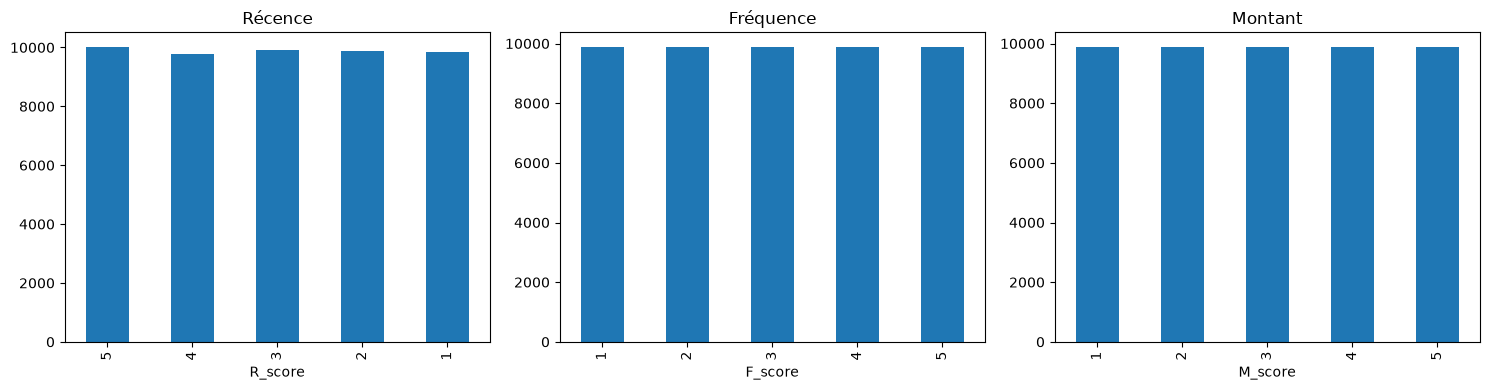

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
rfm["R_score"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Récence")
rfm["F_score"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Fréquence")
rfm["M_score"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Montant")
plt.tight_layout()
plt.show()

Vérifie visuellement que les quintiles sont bien équilibrés (5 barres à peu près égales) — un déséquilibre visible signalerait un problème dans le qcut (souvent dû à trop de valeurs identiques).

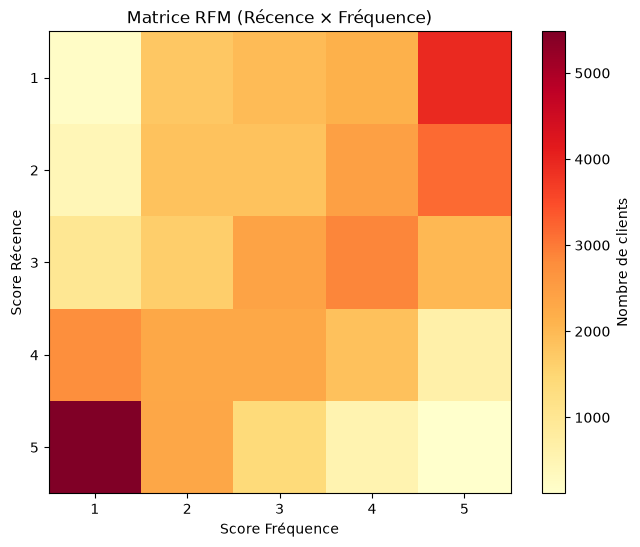

In [12]:
matrix = rfm.groupby(["R_score", "F_score"])["customer_id"].count().unstack()
plt.figure(figsize=(8,6))
plt.imshow(matrix, cmap="YlOrRd")
plt.colorbar(label="Nombre de clients")
plt.xlabel("Score Fréquence")
plt.ylabel("Score Récence")
plt.xticks(range(5), [1,2,3,4,5])
plt.yticks(range(5), [1,2,3,4,5])
plt.title("Matrice RFM (Récence × Fréquence)")
plt.show()

La matrice R×F (Montant en 3e dimension serait illisible en 2D) permet de repérer visuellement où se concentre la masse de clients — utile pour valider si tes règles de segmentation (cellule 10) couvrent bien les zones denses de la matrice.

ETAPE 3

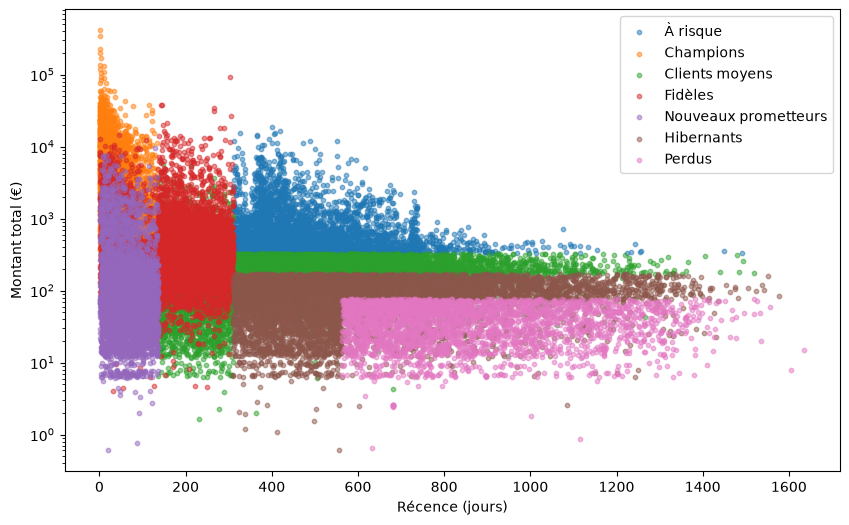

In [13]:
plt.figure(figsize=(10,6))
for seg in rfm["segment"].unique():
    subset = rfm[rfm["segment"] == seg]
    plt.scatter(subset["recency"], subset["monetary"], label=seg, alpha=0.5, s=10)
plt.xlabel("Récence (jours)")
plt.ylabel("Montant total (€)")
plt.yscale("log")
plt.legend()
plt.show()

yscale log : indispensable vu l'asymétrie de monetary (Jour 1 : max à 416k, médiane à 1597€) — sans ça, tous les points s'écraseraient en bas du graphique et la distinction entre segments serait illisible.
 Point de vigilance signalé par l'énoncé : la relation récence/montant n'est pas linéaire — tu peux avoir des clients très récents ET très anciens avec un fort montant (ex: un client ancien fidèle vs un nouveau qui a fait un gros premier achat comme Léa). Le scatter coloré par segment permet de voir ces deux profils distincts au même niveau de montant.

In [14]:
customers_rfm = rfm.merge(customers[["customer_id", "country", "declared_preference", "age_bracket", "life_stage", "urban_density"]], on="customer_id", how="left")

customers_rfm.groupby("segment")["country"].apply(lambda x: x.value_counts(normalize=True).head(3))

segment                             
Champions             France            0.911861
                      Germany           0.022035
                      United Kingdom    0.021241
Clients moyens        France            0.918938
                      Germany           0.015742
                      United Kingdom    0.009868
Fidèles               France            0.905908
                      Germany           0.022264
                      United Kingdom    0.014869
Hibernants            France            0.912943
                      Germany           0.014461
                      United Kingdom    0.013160
Nouveaux prometteurs  France            0.888004
                      United Kingdom    0.028116
                      Germany           0.026242
Perdus                France            0.935893
                      United Kingdom    0.007810
                      Netherlands       0.007485
À risque              France            0.932677
                      Germany   

Croise le segment RFM (comportemental) avec les données démographiques du Jour 1. Attention au biais géographique déjà documenté (91,9% France) : ne t'attends pas à des différences pays marquées entre segments, la France dominera partout — c'est justement une limite à mentionner plutôt qu'un résultat à sur-interpréter.

In [15]:
customers_rfm.groupby("segment")["tenure_days"].mean().sort_values(ascending=False)

segment
Perdus                  854.403711
À risque                761.544439
Hibernants              671.138244
Clients moyens          626.391952
Champions               528.645856
Fidèles                 431.330947
Nouveaux prometteurs     92.432553
Name: tenure_days, dtype: float64

Vérifie la cohérence interne : les Champions et clients À risque doivent logiquement avoir une ancienneté élevée (il faut du temps pour accumuler R,F,M élevés), les Nouveaux prometteurs une ancienneté faible par construction.

In [16]:
customers_rfm.groupby("segment")[["recency", "frequency", "monetary", "avg_basket"]].mean().round(1)

,recency,frequency,monetary,avg_basket
segment,,,,
Champions,58.5,11.1,2473.5,183.9
Clients moyens,459.1,2.3,199.6,108.8
Fidèles,147.0,4.7,560.3,118.1
Hibernants,624.8,1.3,84.6,71.2
Nouveaux prometteurs,63.9,1.2,253.5,182.9
Perdus,854.4,1.0,35.6,35.6
À risque,485.8,4.6,956.8,334.9


ETAPE 4

In [17]:
segment_revenue = customers_rfm.groupby("segment").agg(
    taille=("customer_id", "count"),
    CA_total=("monetary", "sum")
).sort_values("CA_total", ascending=False)
segment_revenue["taille_pct"] = (segment_revenue["taille"] / len(customers_rfm) * 100).round(1)
segment_revenue["CA_pct"] = (segment_revenue["CA_total"] / customers_rfm["monetary"].sum() * 100).round(1)
segment_revenue

,taille,CA_total,taille_pct,CA_pct
segment,,,,
Champions,10075,24920698.33,20.4,63.7
Fidèles,12712,7122927.22,25.7,18.2
À risque,3758,3595797.18,7.6,9.2
Clients moyens,8524,1700968.75,17.3,4.3
Nouveaux prometteurs,4270,1082259.73,8.6,2.8
Hibernants,6937,586917.36,14.0,1.5
Perdus,3126,111269.05,6.3,0.3


Calcule pour chaque segment sa part de la base ET sa part du CA total — c'est cette comparaison (taille vs CA) qui révèle si un segment est "rentable au-delà de sa taille" (Champions) ou au contraire "nombreux mais peu rentable" (Hibernants)

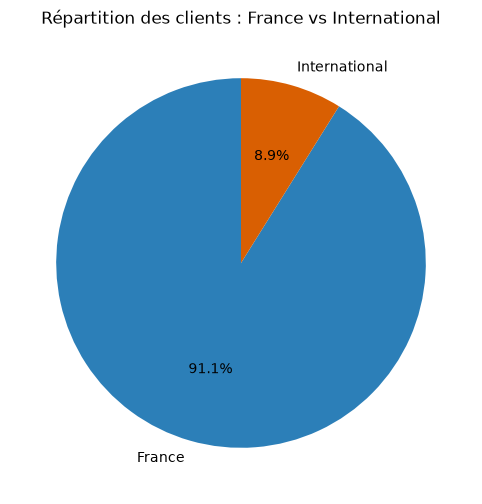

In [20]:
country_split = customers_rfm["country"].apply(lambda x: "France" if x == "France" else "International")
country_pct = country_split.value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(country_pct, labels=country_pct.index, autopct='%1.1f%%', colors=["#2c7fb8", "#d95f02"], startangle=90)
plt.title("Répartition des clients : France vs International")
plt.show()

## Définition des segments RFM

Chaque client est classé dans un segment selon des règles combinant ses 3 scores R, F, M (1 à 5).

**Champions** — R ≥ 4 et F ≥ 4 et M ≥ 4
Les meilleurs clients sur les 3 axes à la fois : achat récent, fréquent, montant élevé.

**À risque** — R ≤ 2 et M ≥ 4
Montant historique élevé mais récence faible : un client de valeur qui décroche.

**Perdus** — R = 1 et F = 1 et M = 1
Le pire score possible sur les 3 dimensions simultanément — le cas le plus extrême.A

*** Nouveaux prometteurs** — R ≥ 4 et F ≤ 2
Achat très récent mais peu de commandes au total : profil typique d'un client tout juste acquis.

*** Fidèles** — R ≥ 3 et F ≥ 3
Bon niveau de récence et de fréquence, sans atteindre le niveau des Champions.

*** Hibernants** — R ≤ 2 et F ≤ 2 et M ≤ 2
Faible sur les 3 dimensions, mais pas au plancher absolu comme les Perdus.

*** Clients moyens** — tous les clients restants
Ne correspond à aucune règle ci-dessus — segment "par défaut" pour éviter que la majorité de la base (qui ne colle à aucun profil extrême) ne soit mal catégorisée.

**Ordre de test important** : les règles sont évaluées dans cet ordre (Champions en premier, Clients moyens en dernier) — un client qui correspondrait à plusieurs règles est classé selon la première qui matche, pour que les profils les plus spécifiques ne soient pas dilués dans un segment plus générique.

### Champions
- **Taille** : 10 075 clients (20,4% de la base)
- **CA généré** : 24,9M€ (63,7% du CA total) — le segment porte à lui seul près des 2/3 du chiffre d'affaires
- **Profil comportemental** : récence 58,5j, fréquence 11,1 commandes, montant moyen 2 473,5€, panier moyen 183,9€
- **Potentiel** : déjà maximal comportementalement — l'enjeu est la rétention, pas la conquête
- **Risque** : faible dans l'immédiat, mais très forte dépendance du CA global à ce seul segment
- **Action** : programme VIP, accès anticipé aux nouveautés, pas de discount (ils achètent déjà au prix plein et fréquemment)

### Fidèles
- **Taille** : 12 712 clients (25,7% de la base) — le plus gros segment
- **CA généré** : 7,1M€ (18,2% du CA total)
- **Profil comportemental** : récence 147j, fréquence 4,7 commandes, montant moyen 560,3€, panier moyen 118,1€
- **Potentiel** : élevé — comportement solide mais net cran en-dessous des Champions sur les 3 dimensions, vivier naturel de progression
- **Risque** : faible à modéré
- **Action** : programme de fidélité incrémental (points, paliers) pour les pousser vers Champions plutôt qu'une offre ponctuelle

### À risque
- **Taille** : 3 758 clients (7,6% de la base)
- **CA généré** : 3,6M€ (9,2% du CA total) — supérieur aux Nouveaux prometteurs et Hibernants réunis malgré une taille plus petite
- **Profil comportemental** : récence 485,8j (inactifs depuis 1 an et demi en moyenne), fréquence passée 4,6 commandes, montant moyen 956,8€, panier moyen 334,9€ — le panier moyen le plus élevé après les Champions
- **Potentiel** : élevé si réactivés — valeur et panier prouvés, ce n'est pas un segment à faible pouvoir d'achat
- **Risque** : churn en cours, avancé (485j sans achat) mais valeur trop importante pour être abandonné
- **Action** : campagne de réactivation ciblée avec offre incitative forte (cf. cas Camille)

### Nouveaux prometteurs
- **Taille** : 4 270 clients (8,6% de la base)
- **CA généré** : 1,08M€ (2,8% du CA total)
- **Profil comportemental** : récence 63,9j, fréquence 1,2 (quasi tous à leur 1ère commande), montant moyen 253,5€, panier moyen 182,9€ — panier proche des Champions dès le premier achat
- **Potentiel** : incertain, dépend entièrement de la conversion vers une 2e/3e commande — mais le panier moyen élevé est un signal encourageant
- **Risque** : abandon après le premier achat si rien n'est fait rapidement
- **Action** : email de bienvenue + recommandation produits complémentaires (cf. cas Léa), fenêtre d'action courte

### Clients moyens
- **Taille** : 8 524 clients (17,3% de la base)
- **CA généré** : 1,7M€ (4,3% du CA total)
- **Profil comportemental** : récence 459,1j, fréquence 2,3, montant moyen 199,6€, panier moyen 108,8€ — comportement globalement faible sur tous les axes, sans être extrême
- **Potentiel** : limité au vu des chiffres réels — plus proche d'un profil "dormant modéré" que d'un vrai potentiel intermédiaire
- **Risque** : glissement progressif vers Hibernants si aucune action
- **Action** : communication standard (newsletter, cross-sell générique) — pas d'investissement ciblé, le retour attendu est trop faible

### Hibernants
- **Taille** : 6 937 clients (14,0% de la base)
- **CA généré** : 587K€ (1,5% du CA total)
- **Profil comportemental** : récence 624,8j, fréquence 1,3, montant moyen 84,6€, panier moyen 71,2€ — les valeurs les plus faibles sur monetary/avg_basket après les Perdus
- **Potentiel** : très faible individuellement, mais le volume (6 937 clients) rend une action low-cost potentiellement rentable en masse
- **Risque** : glissement vers Perdus
- **Action** : relance automatisée low-cost uniquement (email, pas de discount lourd) — le ROI par client ne justifie pas plus

### Perdus
- **Taille** : 3 126 clients (6,3% de la base)
- **CA généré** : 111K€ (0,3% du CA total) — négligeable
- **Profil comportemental** : récence 854,4j (plus de 2 ans d'inactivité en moyenne), fréquence 1,0 (achat unique), montant moyen 35,6€
- **Potentiel** : quasi nul
- **Risque** : déjà réalisé (churn consommé, pas en cours)
- **Action** : exclusion des campagnes coûteuses, communication automatisée uniquement si elle ne coûte rien

## Priorisation

| Rang | Segment | Critère |
|---|---|---|
| 1 | À risque | Risque de perte + valeur prouvée : panier moyen 334,9€ (2e plus élevé), 9,2% du CA en jeu sur seulement 7,6% des clients |
| 2 | Champions | Valeur actuelle : 63,7% du CA total repose sur ce seul segment — coût de négligence maximal |
| 3 | Nouveaux prometteurs | Potentiel de croissance : panier moyen déjà élevé (182,9€) dès la 1ère commande, fenêtre d'action courte (récence 63,9j) |
| 4 | Fidèles | Progression naturelle vers Champions, 18,2% du CA déjà sécurisé, pas d'urgence |
| 5 | Hibernants | Volume important (6 937 clients) mais valeur individuelle faible (84,6€) — rentable seulement en action groupée low-cost |
| 6 | Clients moyens | Segment hétérogène, retour trop incertain pour un ciblage dédié en l'état |
| 7 | Perdus | 0,3% du CA, action minimale justifiée |

**Vérification budget/priorité** : "À risque" (3 758 clients, panier 334,9€) doit recevoir un traitement individualisé coûteux (email personnalisé + offre forte), tandis que "Perdus" (3 126 clients, taille quasi identique) ne reçoit qu'un envoi automatisé à coût nul — malgré des tailles de segment comparables, l'écart de traitement reflète l'écart réel de valeur (3,6M€ vs 111K€ de CA), donc la priorisation n'est pas que théorique ici.

In [21]:
customers_rfm.to_csv("customers_rfm_final.csv", index=False)

HYPOTHESES : 

Je pense que les clients À risque ont une catégorie/un produit dominant différent des Champions, ce qui pourrait expliquer pourquoi ils n'ont pas continué à acheter.

In [22]:
# Je récupère les customer_id de chaque segment
champions_ids = customers_rfm[customers_rfm["segment"] == "Champions"]["customer_id"]
at_risk_ids = customers_rfm[customers_rfm["segment"] == "À risque"]["customer_id"]

# Je regarde la répartition des catégories achetées pour chaque groupe
champions_categories = transactions_clean[transactions_clean["customer_id"].isin(champions_ids)]
at_risk_categories = transactions_clean[transactions_clean["customer_id"].isin(at_risk_ids)]

champions_cat_pct = (champions_categories.groupby("category")["line_total"].sum() / champions_categories["line_total"].sum() * 100).sort_values(ascending=False)
at_risk_cat_pct = (at_risk_categories.groupby("category")["line_total"].sum() / at_risk_categories["line_total"].sum() * 100).sort_values(ascending=False)

comparison_cat = pd.DataFrame({"Champions": champions_cat_pct, "À risque": at_risk_cat_pct}).round(1)
comparison_cat

,Champions,À risque
category,,
Visage,31.9,32.3
Coffret,21.0,22.3
Corps,20.7,20.2
Cheveux,11.3,10.6
Accessoire,8.1,7.9
Bain,7.0,6.7
Frais,0.0,0.0


Je compare la répartition du CA par catégorie entre mes deux segments. Si une catégorie est nettement surreprésentée chez les À risque par rapport aux Champions (ou l'inverse), ça peut indiquer un lien entre le type de produit acheté et le décrochage — mais ça reste à ce stade une corrélation, pas une preuve.

In [23]:
# Pour les clients À risque, je regarde quelle catégorie ils ont achetée en dernier
# avant de cesser d'acheter — c'est potentiellement plus révélateur que le total sur toute la période
last_purchase = transactions_clean[transactions_clean["customer_id"].isin(at_risk_ids)].sort_values("invoice_date")
last_category = last_purchase.groupby("customer_id").tail(1)

last_category["category"].value_counts(normalize=True).head(10) * 100

category
Visage        29.936136
Corps         22.325705
Cheveux       13.517829
Accessoire    13.145290
Bain          10.643960
Coffret        9.765833
Frais          0.665247
Name: proportion, dtype: float64

Plutôt que de regarder tout l'historique d'achat, je me concentre sur le tout dernier produit acheté par chaque client À risque avant son inactivité. Si une catégorie ressort fortement ici, c'est un signal plus direct qu'une catégorie spécifique pourrait être associée à l'arrêt d'achat — par exemple un produit à usage unique/non récurrent, contrairement à un produit consommable qui pousserait normalement au réachat.

In [24]:
# Je compare à la répartition globale des catégories dans TOUT le catalogue,
# pour vérifier que ce n'est pas juste parce que cette catégorie est la plus vendue partout
global_cat_pct = (transactions_clean.groupby("category")["line_total"].sum() / transactions_clean["line_total"].sum() * 100).sort_values(ascending=False)
global_cat_pct

category
Visage        31.897612
Coffret       20.825739
Corps         20.772156
Cheveux       11.280329
Accessoire     8.142515
Bain           7.050007
Frais          0.031642
Name: line_total, dtype: float64

Cette étape est cruciale : si la catégorie qui ressort chez les À risque est aussi la catégorie dominante partout dans mon catalogue (ex: "Visage" à 31,9% vu au Jour 1), alors ce n'est probablement pas un vrai signal — c'est juste le reflet de la popularité générale du produit, pas un lien avec le décrochage. Je ne considère un écart comme intéressant que s'il dépasse nettement la part de cette catégorie dans le catalogue global.

In [25]:
# Catégorie(s) la/les plus achetée(s) par les Champions — sert de base à un programme de fidélité ciblé
champions_cat_pct.head(3)

category
Visage     31.896210
Coffret    21.005957
Corps      20.698686
Name: line_total, dtype: float64

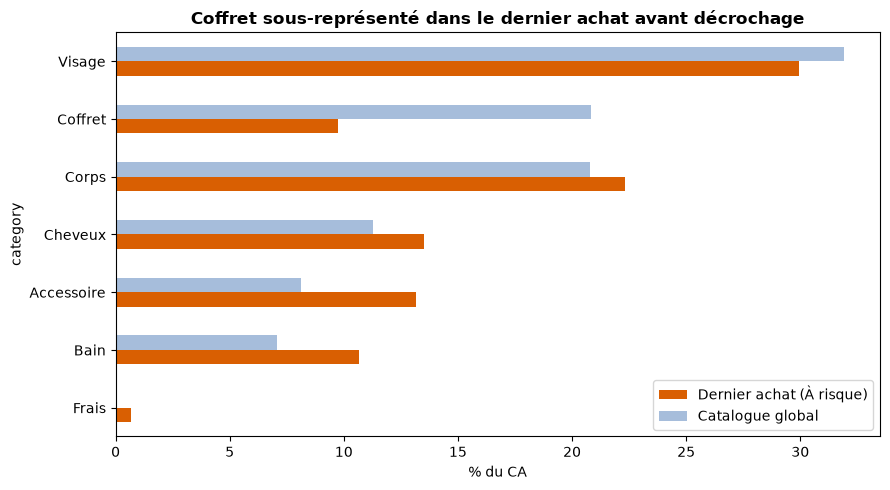

In [26]:
fig, ax = plt.subplots(figsize=(9,5))
compare_last = pd.DataFrame({
    "Dernier achat (À risque)": last_category["category"].value_counts(normalize=True) * 100,
    "Catalogue global": global_cat_pct
}).sort_values("Catalogue global", ascending=True)
compare_last.plot(kind="barh", ax=ax, color=["#d95f02", "#a6bddb"])
ax.set_xlabel("% du CA")
ax.set_title("Coffret sous-représenté dans le dernier achat avant décrochage", fontweight="bold")
plt.tight_layout()
plt.savefig("g2_categories.png", dpi=150)

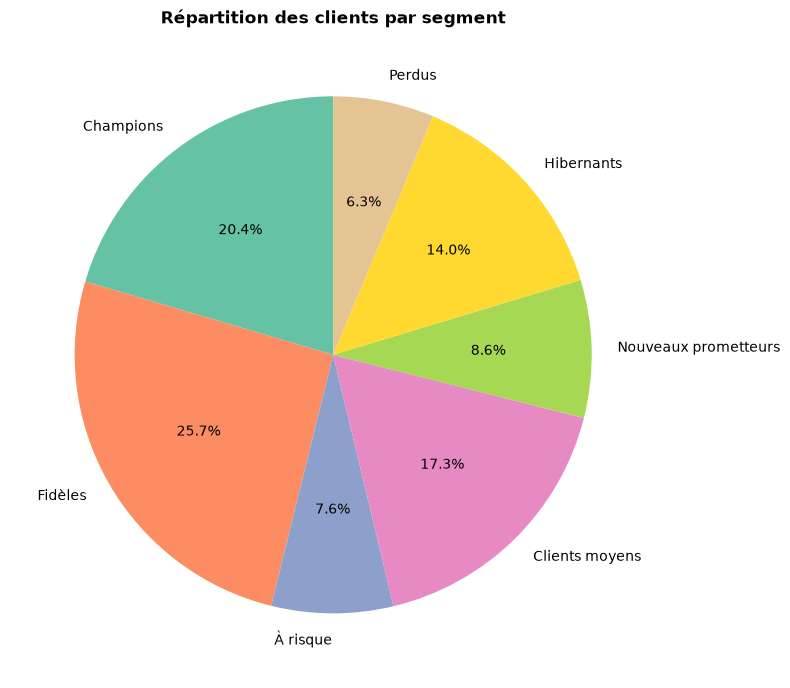

In [31]:


fig, ax = plt.subplots(figsize=(8,8))

palette = plt.cm.Set2(range(len(segment_revenue)))

ax.pie(
    segment_revenue["taille_pct"], 
    labels=segment_revenue.index, 
    autopct='%1.1f%%', 
    colors=palette,
    startangle=90
)
ax.set_title("Répartition des clients par segment", fontweight="bold")
plt.tight_layout()
plt.savefig("g_segments_pie.png", dpi=150)
plt.show()

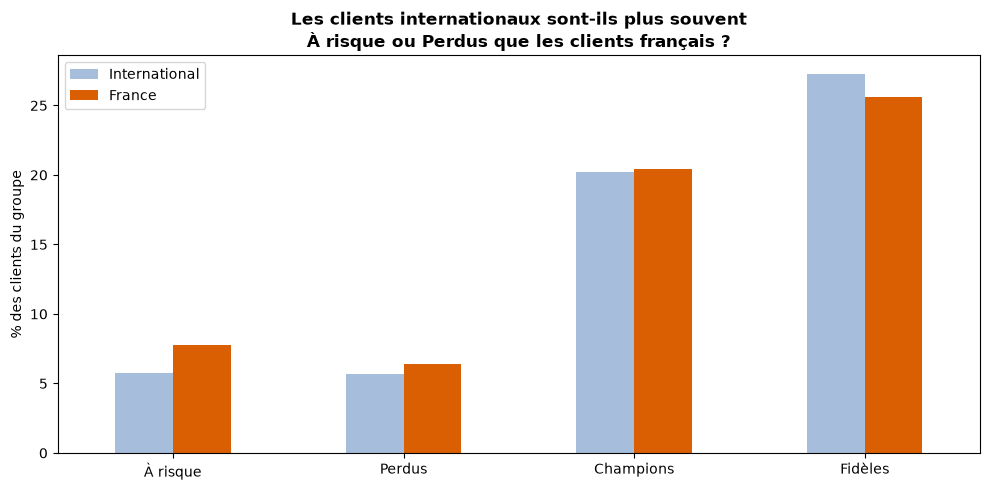

In [32]:


segment_by_geo = pd.crosstab(customers_rfm["is_france"], customers_rfm["segment"], normalize="index") * 100
segment_by_geo.index = ["International", "France"]  # adapte selon ce que renvoie is_france (True/False)

fig, ax = plt.subplots(figsize=(10,5))
segment_by_geo[["À risque", "Perdus", "Champions", "Fidèles"]].T.plot(kind="bar", ax=ax, color=["#a6bddb", "#d95f02"])
ax.set_ylabel("% des clients du groupe")
ax.set_title("Les clients internationaux sont-ils plus souvent\nÀ risque ou Perdus que les clients français ?", fontweight="bold")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.savefig("g_geo_segments.png", dpi=150)
plt.show()

In [35]:
touchpoints["timestamp"] = pd.to_datetime(touchpoints["timestamp"])

# Date de référence pour chaque client : sa dernière date d'achat connue (snapshot_date pour les actifs)
customers_rfm_dates = customers_rfm.merge(
    transactions_clean.groupby("customer_id")["invoice_date"].max().rename("last_activity"),
    on="customer_id", how="left"
)

# Je regarde les touchpoints reçus dans les 90 jours PRÉCÉDANT cette date de référence
touchpoints_with_ref = touchpoints.merge(
    customers_rfm_dates[["customer_id", "last_activity", "segment"]], on="customer_id", how="left"
)
touchpoints_with_ref["days_before_ref"] = (touchpoints_with_ref["last_activity"] - touchpoints_with_ref["timestamp"]).dt.days

recent_touchpoints = touchpoints_with_ref[
    (touchpoints_with_ref["days_before_ref"] >= 0) & (touchpoints_with_ref["days_before_ref"] <= 90)
]

touchpoints_90j_by_segment = recent_touchpoints.groupby("customer_id").size().reindex(customers_rfm["customer_id"], fill_value=0)
touchpoints_90j_by_segment = touchpoints_90j_by_segment.to_frame("nb_touchpoints_90j").merge(
    customers_rfm[["customer_id", "segment"]], on="customer_id"
)

avg_touchpoints = touchpoints_90j_by_segment.groupby("segment")["nb_touchpoints_90j"].mean().sort_values(ascending=False)
avg_touchpoints

segment
Champions               14.111960
Fidèles                  9.671098
Nouveaux prometteurs     6.545902
Clients moyens           2.414711
À risque                 0.929484
Hibernants               0.329681
Perdus                   0.000000
Name: nb_touchpoints_90j, dtype: float64

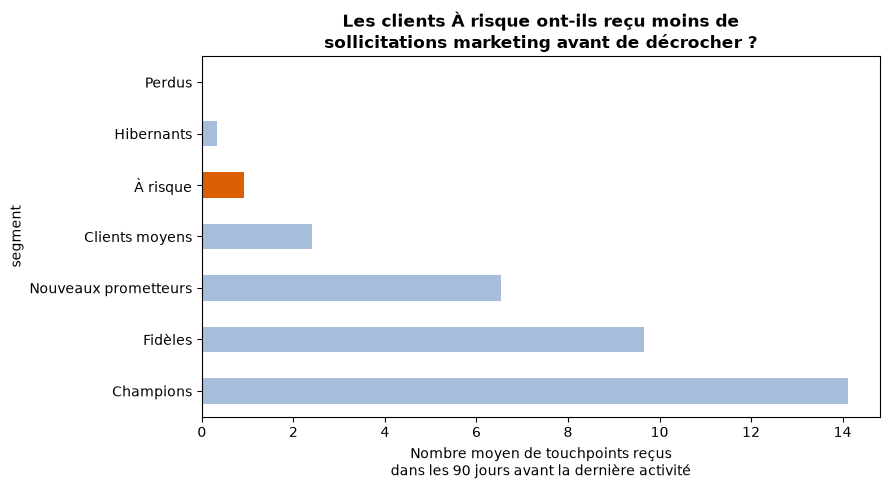

In [36]:
fig, ax = plt.subplots(figsize=(9,5))
colors = ["#d95f02" if seg == "À risque" else "#a6bddb" for seg in avg_touchpoints.index]
avg_touchpoints.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Nombre moyen de touchpoints reçus\ndans les 90 jours avant la dernière activité")
ax.set_title("Les clients À risque ont-ils reçu moins de\nsollicitations marketing avant de décrocher ?", fontweight="bold")
plt.tight_layout()
plt.savefig("g_touchpoints_avant_decrochage.png", dpi=150)
plt.show()

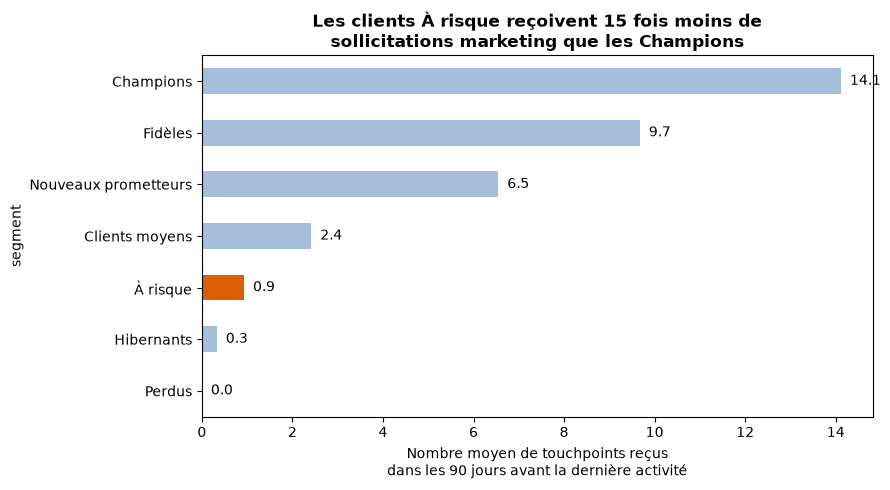

In [37]:
import matplotlib.pyplot as plt

avg_touchpoints = avg_touchpoints.sort_values(ascending=True)  # pour un ordre croissant en barres horizontales

fig, ax = plt.subplots(figsize=(9,5))
colors = ["#d95f02" if seg == "À risque" else "#a6bddb" for seg in avg_touchpoints.index]

avg_touchpoints.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Nombre moyen de touchpoints reçus\ndans les 90 jours avant la dernière activité")
ax.set_title("Les clients À risque reçoivent 15 fois moins de\nsollicitations marketing que les Champions", fontweight="bold")

for i, v in enumerate(avg_touchpoints):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.savefig("g_touchpoints_avant_decrochage.png", dpi=150)
plt.show()